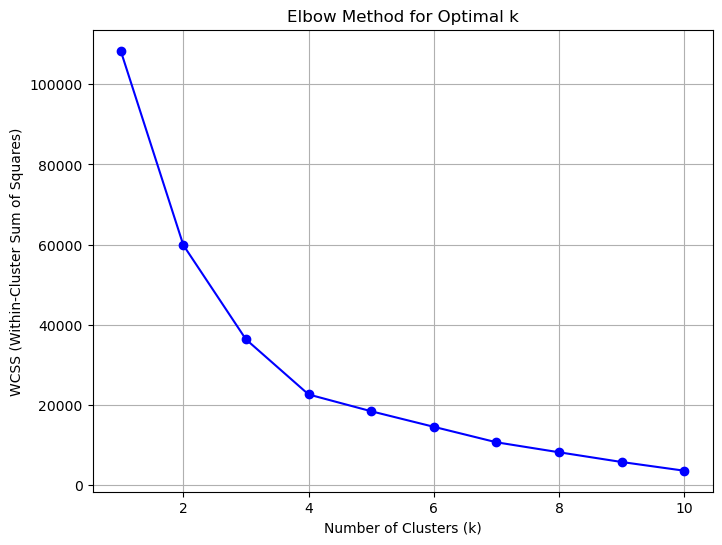

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Load your DESeq2 normalized counts table (ensure it's in a pandas DataFrame)
# Replace 'normalized_counts.csv' with your actual file name
normalized_counts = pd.read_csv('/home/nanopore/projects/rna_seq_workflow/results/20240716_FOXY/DEG_analysis/20240716_FOXY_normalized_counts.csv', index_col=0)

# Standardize the data (scale the features)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(normalized_counts.T)  # Transpose to scale across samples

# Create an empty list to store WCSS (Within-Cluster Sum of Squares) for different k values
wcss = []

# Try clustering for k values from 1 to 10
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)  # inertia_ is the WCSS

# Plot the Elbow Graph
plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='-', color='b')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.grid(True)
plt.show()

